# 1 — Encoded tire force: what each physical prior buys

This notebook walks the **ablation ladder** of `tire_physics_nn` on direct tire-force
data and measures, for each rung, both the accuracy and the *physical violations*.

The claim being tested is narrow and checkable:

> Symmetry and the friction envelope, when encoded in the architecture, hold exactly
> for any weights — before training, after training, and outside the training range —
> while a penalty only holds approximately on the training distribution.

See the docs chapters **Symmetry (P2)** and
**Friction envelope (P3)** for the
derivations.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True, "grid.alpha": 0.3})
from tire_nn.training import set_seed
set_seed(0)
print("torch", torch.__version__)

/home/poxx/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


torch 2.13.0+cu130


## 1. The data

Synthetic Magic-Formula ground truth, so the true function is known outside the
training range. Every real adapter returns the same canonical schema
(`alpha` [rad], `kappa` [-], `Fz` [N], `Fx`/`Fy` [N], SAE signs), so swapping in
`adapters.load("kit", ...)` changes nothing below.

In [2]:
from tire_nn.data import make_synthetic, split_by_group, TireDataset

df = make_synthetic(n=4000, mu=1.1, B=9.0, C=1.6, E=0.4, noise=0.01, seed=0)
train_df, val_df, test_df = split_by_group(df, fractions=(0.7, 0.15, 0.15), seed=0)
print(f"train {len(train_df)}  val {len(val_df)}  test {len(test_df)}")
df.head(3).round(3)

train 2800  val 600  test 600


,alpha,kappa,Fz,Fx,Fy,tire_id,source
0,0.068,0.052,1782.789,984.701,-1144.548,synthetic,synthetic
1,-0.115,0.006,1901.204,75.403,1753.511,synthetic,synthetic
2,-0.230,-0.020,1887.273,-157.178,1906.678,synthetic,synthetic


## 2. Untrained models already differ

Before any fitting, evaluate every model on a grid **wider** than the training range —
this is where violations live, and where a racing controller operates.

In [3]:
from tire_nn.models import (MLPTireModel, SymmetryTireNet, EncodedTireNet,
                             ParameterTireNet, ResidualTireNet)
from tire_nn.physics import MagicFormulaTire
from tire_nn.physics.fitting import fit_magic_formula
from tire_nn.evaluation import audit_table

px, py = fit_magic_formula(train_df)
print("fitted Magic Formula (lateral): "
      f"mu={float(py.mu):.3f}  B={float(py.B):.2f}  C={float(py.C):.2f}  "
      f"E={float(py.E):.2f}  k_mu={float(py.k_mu):.3f}")

untrained = {
    "magic_formula": MagicFormulaTire(px, py),
    "mlp": MLPTireModel(hidden=(64, 64)),
    "symmetry": SymmetryTireNet(),
    "encoded": EncodedTireNet(),
    "parameter": ParameterTireNet(),
}
audit_table(untrained, n=4096, alpha_max=0.6, kappa_max=0.6).round(6)

fitted Magic Formula (lateral): mu=1.098  B=9.45  C=1.35  E=0.01  k_mu=0.079


,model,sym_violation_x,sym_violation_y,zero_slip_force,zero_alpha_Fy,zero_kappa_Fx,envelope_violation,envelope_violation_frac,dissipativity_violation
0,magic_formula,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
1,mlp,0.24177,0.392165,0.216309,0.360765,0.15211,0.000000,0.000000,0.182985
2,symmetry,0.00000,0.000000,0.000000,0.000000,0.00000,7.763438,0.968506,0.000000
3,encoded,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
4,parameter,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000


Read the columns:

* `zero_slip_force` — force at $\alpha=\kappa=0$, load-normalised. Only the MLP has any.
* `sym_violation_y` — $|F_y(\alpha)+F_y(-\alpha)|$. Zero by construction for every
  encoded model.
* `envelope_violation` — how far outside the friction ellipse the model goes. Note that
  `symmetry` (no envelope) is the **worst** of all: an unconstrained magnitude with a
  correct shape.
* `dissipativity_violation` — force pointing *along* the slip instead of against it.

## 3. Train the ladder

Identical data, optimiser, seed and budget for every rung, so a difference is
attributable to the prior. The `mlp_penalty` rung is the control: same architecture as
`mlp`, plus a soft friction-ellipse penalty in the loss.

In [4]:
from tire_nn.training import TrainConfig, train_model

make_ds = lambda d: TireDataset(d, targets=("Fx", "Fy"))
base = dict(epochs=50, batch_size=256, lr=3e-3, patience=15,
            targets=("Fx", "Fy"), loss="mse", normalize_by_load=True)

models = {
    "magic_formula": MagicFormulaTire(px, py),          # fitted, not trained
    "mlp": MLPTireModel(hidden=(64, 64)),
    "mlp_penalty": MLPTireModel(hidden=(64, 64)),
    "symmetry": SymmetryTireNet(),
    "encoded": EncodedTireNet(),
    "parameter": ParameterTireNet(),
    "residual": ResidualTireNet(px=px, py=py),
}

for name, model in models.items():
    if name == "magic_formula":
        continue
    cfg = TrainConfig(**base)
    if name == "mlp_penalty":
        cfg.friction_penalty_weight = 1.0     # the soft-constraint ablation
    train_model(model, make_ds(train_df), make_ds(val_df), cfg, verbose=False)
    model.eval()
    print(f"{name:14s} trained  ({sum(p.numel() for p in model.parameters()):5d} params)")

mlp            trained  ( 4546 params)


mlp_penalty    trained  ( 4546 params)


symmetry       trained  ( 1250 params)


encoded        trained  ( 1254 params)


parameter      trained  ( 1483 params)


residual       trained  ( 1254 params)


## 4. Accuracy and violations side by side

In [5]:
from tire_nn.evaluation import evaluate_on, slip_range_holdout
from tire_nn.evaluation.physical_consistency import audit

inner_df, outer_df = slip_range_holdout(df, alpha_train_max=0.12, kappa_train_max=0.12)

rows = []
for name, model in models.items():
    row = {"model": name, "params": sum(p.numel() for p in model.parameters())}
    row.update({f"test_{k}": v for k, v in evaluate_on(model, test_df, ("Fy",)).items()})
    row.update({f"extrap_{k}": v for k, v in evaluate_on(model, outer_df, ("Fy",)).items()})
    # Audit against two friction limits. mu_ref=1.5 is deliberately generous — a
    # violation of it is unambiguous. mu_ref=1.1 is the true mu of this data, i.e. the
    # limit a controller would actually plan against.
    generous = audit(model, n=4096, alpha_max=0.6, kappa_max=0.6, mu_ref=1.5)
    true_mu = audit(model, n=4096, alpha_max=0.6, kappa_max=0.6, mu_ref=1.1)
    row.update({k: generous[k] for k in ("zero_slip_force", "sym_violation_y",
                                         "dissipativity_violation")})
    row["envelope_violation_mu1.5"] = generous["envelope_violation"]
    row["envelope_violation_mu1.1"] = true_mu["envelope_violation"]
    rows.append(row)

summary = pd.DataFrame(rows)[
    ["model", "params", "test_Fy_rmse", "extrap_Fy_rmse", "zero_slip_force",
     "sym_violation_y", "envelope_violation_mu1.5", "envelope_violation_mu1.1"]]
summary.round(5)

,model,params,test_Fy_rmse,extrap_Fy_rmse,zero_slip_force,sym_violation_y,envelope_violation_mu1.5,envelope_violation_mu1.1
0,magic_formula,0,18.01142,17.16352,0.00000,0.00000,0.00000,0.00000
1,mlp,4546,21.58279,20.42227,0.04946,0.17309,0.00000,0.06293
2,mlp_penalty,4546,21.14133,21.48743,0.03278,0.10366,0.00000,0.07701
3,symmetry,1250,42.15678,35.88054,0.00000,0.00000,0.91645,1.61334
4,encoded,1254,20.01769,19.15640,0.00000,0.00000,0.00000,0.00000
5,parameter,1483,17.82637,17.11874,0.00000,0.00000,0.00000,0.00000
6,residual,1254,19.00368,17.53440,0.00000,0.00000,0.00000,0.00000


### The penalty ablation

`mlp` and `mlp_penalty` are the same architecture; only the loss differs. The comparison
below reports what actually happened in *this* run rather than asserting a conclusion —
whether a soft constraint helps depends on how far the fitted model strays in the first
place, which depends on the data and the budget.

In [6]:
pen = summary.set_index("model")
TOL = 1e-6

for limit in ("envelope_violation_mu1.5", "envelope_violation_mu1.1"):
    plain, soft = pen.loc["mlp", limit], pen.loc["mlp_penalty", limit]
    print(f"{limit}:")
    print(f"   plain MLP           {plain:.4f}")
    print(f"   MLP + penalty       {soft:.4f}", end="")
    if plain > TOL:
        delta = soft / plain - 1.0
        verdict = "WORSE" if delta > 0 else "better"
        print(f"   ({verdict} than the plain MLP by {abs(delta) * 100:.0f}%)")
    else:
        print("   (plain MLP did not violate this limit, so there was nothing to fix)")
    print(f"   encoded (structural) {pen.loc['encoded', limit]:.2e}")

print("")
print("What the penalty can never fix, because it is not in the loss:")
print(f"   zero-slip force  mlp {pen.loc['mlp', 'zero_slip_force']:.4f}  "
      f"mlp_penalty {pen.loc['mlp_penalty', 'zero_slip_force']:.4f}  "
      f"encoded {pen.loc['encoded', 'zero_slip_force']:.0f}")
print(f"   odd symmetry     mlp {pen.loc['mlp', 'sym_violation_y']:.4f}  "
      f"mlp_penalty {pen.loc['mlp_penalty', 'sym_violation_y']:.4f}  "
      f"encoded {pen.loc['encoded', 'sym_violation_y']:.0f}")

envelope_violation_mu1.5:
   plain MLP           0.0000
   MLP + penalty       0.0000   (plain MLP did not violate this limit, so there was nothing to fix)
   encoded (structural) 1.19e-07
envelope_violation_mu1.1:
   plain MLP           0.0629
   MLP + penalty       0.0770   (WORSE than the plain MLP by 22%)
   encoded (structural) 1.19e-07

What the penalty can never fix, because it is not in the loss:
   zero-slip force  mlp 0.0495  mlp_penalty 0.0328  encoded 0
   odd symmetry     mlp 0.1731  mlp_penalty 0.1037  encoded 0


## 5. What the models actually look like

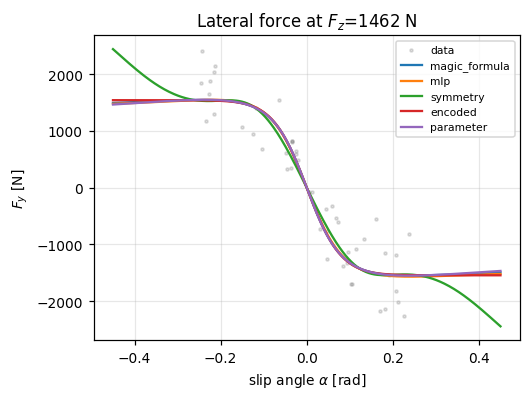

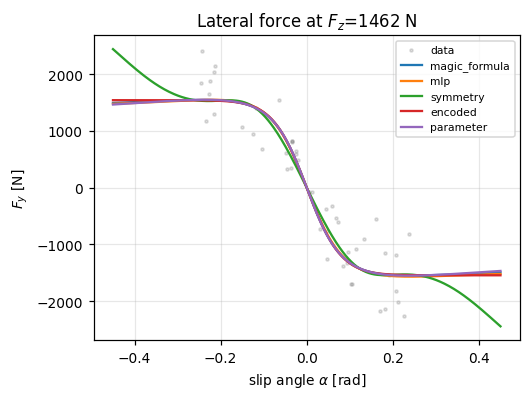

In [7]:
from tire_nn.evaluation import plots

show = {k: models[k] for k in ("magic_formula", "mlp", "symmetry", "encoded", "parameter")}
Fz_plot = float(train_df["Fz"].median())
fig = plots.plot_lateral_curve(show, Fz=Fz_plot, alpha_max=0.45,
                               data=test_df[test_df["kappa"].abs() < 0.02])
fig

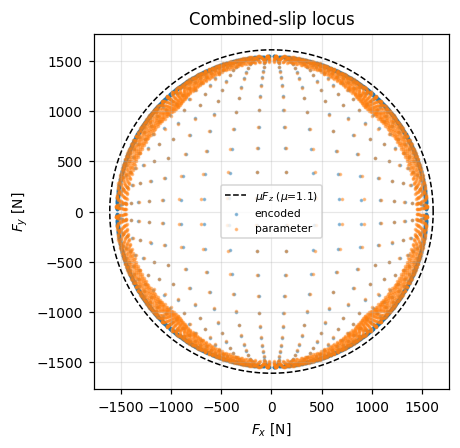

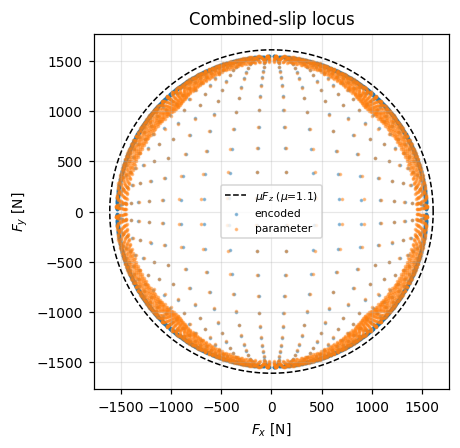

In [8]:
fig = plots.plot_friction_ellipse({k: models[k] for k in ("encoded", "parameter")},
                                  Fz=Fz_plot, mu=1.1)
fig

## 6. Reading the learned parameters

Only `ParameterTireNet` gives back a *tire* rather than a curve: peak friction,
cornering stiffness and relaxation length, all inside their declared physical ranges.

In [9]:
Fz = torch.linspace(300, 3000, 7)
p = models["parameter"].parameters_at(Fz)
out = models["parameter"](torch.full_like(Fz, 0.05), torch.zeros_like(Fz), Fz)
pd.DataFrame({
    "Fz [N]": Fz.numpy().round(0),
    "mu_y (at Fz)": out.params["mu_y"].detach().numpy().round(3),
    "B_y": p["B_y"].detach().numpy().round(2),
    "C_y": p["C_y"].detach().numpy().round(2),
    "C_alpha [N/rad]": out.params["C_alpha"].detach().numpy().round(0),
    "sigma_y [m]": p["sigma_y"].detach().numpy().round(3),
})

,Fz [N],mu_y (at Fz),B_y,C_y,C_alpha [N/rad],sigma_y [m]
0,300.0,1.161,8.59,1.52,4548.0,0.3
1,750.0,1.124,8.55,1.52,10957.0,0.3
2,1200.0,1.084,8.51,1.52,16844.0,0.3
3,1650.0,1.043,8.50,1.52,22256.0,0.3
4,2100.0,1.003,8.50,1.52,27276.0,0.3
5,2550.0,0.966,8.52,1.52,31972.0,0.3
6,3000.0,0.932,8.55,1.52,36387.0,0.3


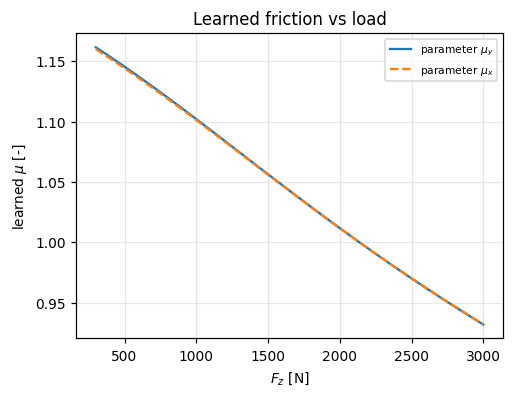

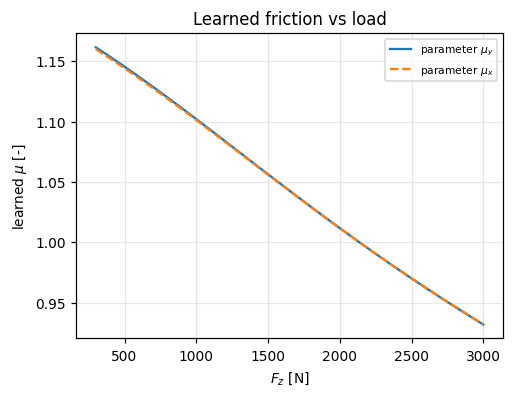

In [10]:
fig = plots.plot_learned_mu({"parameter": models["parameter"]}, Fz_range=(300.0, 3000.0))
fig

## 7. Performance vs amount of training data

The practical question for a tire programme: how much rig time does each model need?

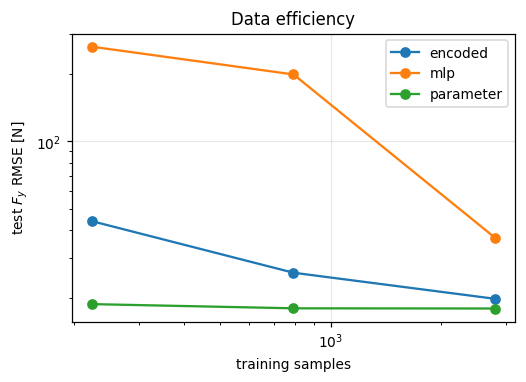

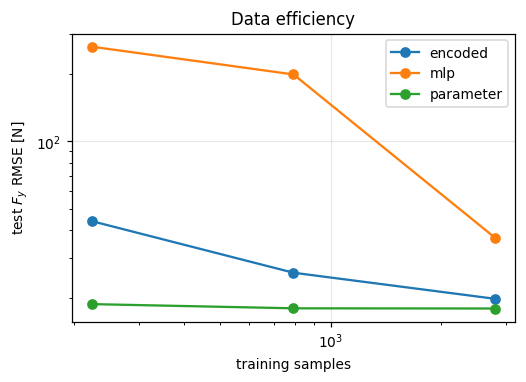

In [11]:
from tire_nn.evaluation import learning_curve_sizes

sizes = learning_curve_sizes(len(train_df), points=3, min_frac=0.08)
curve = []
for n in sizes:
    subset = train_df.iloc[:n]
    for name in ("mlp", "encoded", "parameter"):
        cls = {"mlp": MLPTireModel, "encoded": EncodedTireNet, "parameter": ParameterTireNet}[name]
        m = cls()
        train_model(m, make_ds(subset), make_ds(val_df),
                    TrainConfig(**{**base, "epochs": 30, "patience": 10}), verbose=False)
        curve.append({"n_train": n, "model": name,
                      "test_Fy_rmse": evaluate_on(m.eval(), test_df, ("Fy",))["Fy_rmse"]})
curve = pd.DataFrame(curve)
fig, ax = plt.subplots(figsize=(5.2, 3.4))
for name, g in curve.groupby("model"):
    ax.plot(g["n_train"], g["test_Fy_rmse"], "o-", label=name)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("training samples"); ax.set_ylabel("test $F_y$ RMSE [N]")
ax.set_title("Data efficiency"); ax.legend()
fig

In [12]:
best = summary.sort_values("test_Fy_rmse").iloc[0]
enc, mlp_row = pen.loc["encoded"], pen.loc["mlp"]
print(f"most accurate model here      : {best['model']} ({best['test_Fy_rmse']:.1f} N test RMSE)")
print(f"encoded vs MLP parameters     : {enc['params']:.0f} vs {mlp_row['params']:.0f} "
      f"({mlp_row['params'] / enc['params']:.1f}x fewer)")
print(f"encoded vs MLP test RMSE      : {enc['test_Fy_rmse']:.1f} N vs {mlp_row['test_Fy_rmse']:.1f} N")
print(f"encoded vs MLP extrapolation  : {enc['extrap_Fy_rmse']:.1f} N vs {mlp_row['extrap_Fy_rmse']:.1f} N")
print(f"models with exactly zero physical violations: "
      f"{sorted(summary.loc[(summary[['zero_slip_force','sym_violation_y','envelope_violation_mu1.1']].max(axis=1) < 1e-6), 'model'])}")

most accurate model here      : parameter (17.8 N test RMSE)
encoded vs MLP parameters     : 1254 vs 4546 (3.6x fewer)
encoded vs MLP test RMSE      : 20.0 N vs 21.6 N
encoded vs MLP extrapolation  : 19.2 N vs 20.4 N
models with exactly zero physical violations: ['encoded', 'magic_formula', 'parameter', 'residual']


## Takeaways

1. The encoded models satisfy zero-slip, symmetry and the friction envelope **exactly**
   — untrained, trained, and outside the training range. That is the one claim in this
   notebook that does not depend on the data, the budget or the seed.
2. Accuracy differences between a well-trained MLP and an encoded model on *plentiful,
   clean, in-distribution* data are modest. The priors earn their keep where data is
   scarce (section 7), off-distribution, and in the guarantees a controller needs.
3. Whether the soft penalty helps depends on how far the unconstrained fit strays in
   the first place — which is exactly the problem with a penalty: it is a property of
   the run, not of the model. The structural version is a property of the model.
4. **Caveats.** The data is Magic-Formula generated, so `ParameterTireNet` matches the
   generating structure exactly and its win is expected. And the noise here is clean
   Gaussian on a dense slip grid — kinder than any real rig. Re-run on real data
   (`adapters.load("kit", ...)`) before drawing conclusions about relative accuracy.